# 09a — Block Bootstrap Power Analysis and Bootstrap-Method Audit

**Pipeline stage 9a of 9.** Re-runs the bootstrap-based statistical tests from notebooks 03, 04, 07, and 09 using a moving-block bootstrap that preserves the autocorrelation structure of bloom weeks, then sweeps the effective sample size to ask whether the directionally-observed validator differences would become Holm-significant at larger test lengths.

**Why this exists.** Notebook 09 cell 24 (the validator paired-bootstrap test) and the manuscript's Table 3 CIs both use IID bootstrap (`rng.choice(n, size=n, replace=True)`), which assumes independent observations. Bloom weeks cluster in time — once a bloom starts, the next 4–12 weeks are bloom weeks at >80% probability — so IID resampling destroys that clustering and produces CIs that are slightly too narrow. The fix is a moving-block bootstrap that resamples *consecutive runs of weeks* rather than individual weeks.

**Three jobs in this notebook**

1. **Block-length robustness check.** Re-compute the standalone-LSTM Brier-score CI at block lengths 8, 12, 16 to confirm the result is stable across the autocorrelation timescale.
2. **Bootstrap-method audit.** Re-compute Table 3 model-level CIs and notebook 09's validator paired-bootstrap tests with proper block resampling. Compare to the IID results.
3. **Power analysis.** Sweep effective sample size at scales {1×, 2×, 5×, 10×} of the current 216-week test length. Plot Holm-corrected p-values as a function of scale per validator-comparison metric. Identify the scale (if any) at which directionally-observed differences cross significance.

**Outputs (`output_refactored/block_bootstrap/`)**
- `Table9_block_bootstrap_audit.csv` — IID vs block bootstrap CI comparison for Table 3 metrics
- `Table9_validator_block_bootstrap.csv` — validator paired tests recomputed with block bootstrap
- `Table9_power_analysis.csv` — Holm-corrected p-values per (alt model × metric × scale)
- `Fig9L_block_length_robustness.png/.pdf`
- `Fig9M_power_analysis.png/.pdf`

**Caveat: what the power analysis can and cannot say.** Scale 10× draws 10× as many *weeks* from the same 216 underlying weeks. Each onset event in the test set may be sampled many times in any given resample. The power analysis answers "given that real-world dynamics produce onsets like the ones in this test set, what precision would more weeks of the same kind of data yield?" — not "what would happen under a different bloom regime." That second question requires a generative simulator and is left to follow-up work.


## Setup

In [1]:
import os
import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, brier_score_loss
)

from shared_config import *
print_config_summary()

SEED = 42
np.random.seed(SEED)

BLOCK_BOOTSTRAP_DIR = os.path.join(OUTPUT_DIR, "block_bootstrap")
os.makedirs(BLOCK_BOOTSTRAP_DIR, exist_ok=True)

plt.rcdefaults()
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "axes.labelsize": 11, "axes.titlesize": 12,
    "xtick.labelsize": 9, "ytick.labelsize": 9, "legend.fontsize": 9,
    "figure.dpi": 300, "savefig.dpi": 300, "savefig.bbox": "tight",
    "axes.spines.top": False, "axes.spines.right": False,
})


def savefig(fig, stem):
    for ext in ("png", "pdf"):
        fp = os.path.join(BLOCK_BOOTSTRAP_DIR, f"{stem}.{ext}")
        fig.savefig(fp, dpi=300, bbox_inches="tight")
        print(f"  saved {fp}")


def display_df(df):
    try:
        display(df)
    except NameError:
        print(df.to_string(index=False))


def save_table(df, fname, title=None):
    fp = os.path.join(BLOCK_BOOTSTRAP_DIR, fname)
    df.to_csv(fp, index=False)
    print(f"  saved {fp}")
    if title:
        print(f"  {title}")
    display_df(df)


--- Workflow Configuration Summary ---
Enhanced Features Enabled:     True
Scaler Type Selected:          Robust
Class Weighting Enabled:       True
Hyperparameter Tuning Enabled: True
EnKF Enabled:                  True
FAST_TEST Mode:                False
Sequence Length (default):     26
Forecast Horizon:              1 week(s)
Output directory:              output_refactored/
--------------------------------------


## Load probability streams and validator thresholds

Same inputs notebook 09 uses: the per-model probability streams from notebook 06's persistence cell, plus the threshold values selected by F1-maximization on the validation set in notebooks 03 and 04.

In [2]:
if not os.path.exists(ALT_MODEL_STREAMS_PATH):
    raise FileNotFoundError(
        f"Missing {ALT_MODEL_STREAMS_PATH}. Run notebook 06 first.")

data = np.load(ALT_MODEL_STREAMS_PATH)
streams = {k: data[k].astype(float).flatten() for k in data.files}

# Backstop: load standalone and EnKF probs from their dedicated files if absent.
if "lstm" not in streams and os.path.exists(LSTM_TEST_PROBS_PATH):
    streams["lstm"] = np.load(LSTM_TEST_PROBS_PATH).astype(float).flatten()
if "lstm_enkf_preprocessor" not in streams and os.path.exists(LSTM_ENKF_TEST_PROBS_PATH):
    streams["lstm_enkf_preprocessor"] = np.load(LSTM_ENKF_TEST_PROBS_PATH).astype(float).flatten()

assert "y_test" in streams, "y_test missing from streams"
y_test = streams["y_test"].astype(int)
n_test = len(y_test)
print(f"Loaded {len(streams)} streams. Test length: n = {n_test} weeks. Bloom rate: {y_test.mean():.3f}")
for k in sorted(streams.keys()):
    print(f"  {k}: shape={streams[k].shape}")

# Thresholds tuned on validation set (notebooks 03 and 04).
def _load_threshold(path, fallback=0.5):
    if not os.path.exists(path):
        return float(fallback)
    with open(path) as f:
        j = json.load(f)
    for key in ("optimal_threshold_full", "optimal_threshold", "threshold", "best_threshold"):
        if key in j:
            return float(j[key])
        if "metrics" in j and isinstance(j["metrics"], dict) and key in j["metrics"]:
            return float(j["metrics"][key])
    return float(fallback)

STANDALONE_THRESHOLD = _load_threshold(BASELINE_METRICS_PATH)
ENKF_THRESHOLD = _load_threshold(LSTM_ENKF_METRICS_PATH)
print(f"\nStandalone LSTM threshold: {STANDALONE_THRESHOLD:.4f}")
print(f"LSTM-EnKF validator threshold: {ENKF_THRESHOLD:.4f}")

validator_specs = {
    "Standalone LSTM":      {"key": "lstm",                     "threshold": STANDALONE_THRESHOLD},
    "LSTM-EnKF validator":  {"key": "lstm_enkf_preprocessor",   "threshold": ENKF_THRESHOLD},
}

name_map = {
    "var":              "VAR",
    "regime_switching": "Regime-switching",
    "pinn":             "PINN-augmented LSTM",
    "lstm_gp":          "LSTM + GP",
    "hybrid_ensemble":  "Hybrid ensemble",
}
alternate_keys = [k for k in streams if k in name_map]
print(f"\nAlternative models present: {[name_map[k] for k in alternate_keys]}")


def align_tail(*arrays):
    """Right-align arrays to the shortest (matches notebook 09 convention)."""
    n = min(len(a) for a in arrays)
    return tuple(np.asarray(a)[-n:] for a in arrays)


Loaded 8 streams. Test length: n = 216 weeks. Bloom rate: 0.324
  hybrid_ensemble: shape=(216,)
  lstm: shape=(216,)
  lstm_enkf_preprocessor: shape=(216,)
  lstm_gp: shape=(216,)
  pinn: shape=(216,)
  regime_switching: shape=(216,)
  var: shape=(216,)
  y_test: shape=(216,)

Standalone LSTM threshold: 0.5000
LSTM-EnKF validator threshold: 0.5000

Alternative models present: ['VAR', 'Regime-switching', 'PINN-augmented LSTM', 'LSTM + GP', 'Hybrid ensemble']


## Moving-block bootstrap implementation

For a series of length `n` and block length `L`, we sample `ceil(target / L)` starting positions uniformly from `[0, n − L]`, concatenate the `L` consecutive observations at each start, and trim to `target`. This is the standard moving-block bootstrap of Künsch (1989); the alternative non-overlapping-blocks scheme of Carlstein (1986) was rejected because the small test set (n = 216, ≈18 non-overlapping blocks at L = 12) would produce unacceptably lumpy bootstrap distributions.

Within each resample the autocorrelation structure inside each block is preserved exactly; only the order and identity of blocks varies. A bloom cluster that spans, say, weeks 50–60 stays intact inside whichever block contains it. If a block is sampled twice in a resample, that cluster appears twice; if not sampled, absent.

In [3]:
def moving_block_bootstrap_indices(n, block_length, target_length, rng):
    """Return a 1-D array of length target_length with indices in [0, n).

    Indices are produced by concatenating consecutive runs of `block_length`
    starting at uniformly-random positions in [0, n - block_length].
    """
    if block_length < 1 or block_length > n:
        raise ValueError(f"block_length {block_length} invalid for n={n}")
    max_start = n - block_length + 1
    n_blocks_needed = int(np.ceil(target_length / block_length))
    starts = rng.integers(0, max_start, size=n_blocks_needed)
    # Build all blocks at once with broadcasting
    block_offsets = np.arange(block_length)
    idx = (starts[:, None] + block_offsets[None, :]).reshape(-1)
    return idx[:target_length]


def iid_bootstrap_indices(n, target_length, rng):
    """For comparison: standard IID bootstrap (what nb09 cell 24 currently does)."""
    return rng.integers(0, n, size=target_length)


# Quick visual sanity check that the block bootstrap preserves autocorrelation.
from numpy import corrcoef

rng = np.random.default_rng(SEED)
acf_orig = float(corrcoef(y_test[:-1], y_test[1:])[0, 1])

block_acfs, iid_acfs = [], []
for _ in range(500):
    idx_b = moving_block_bootstrap_indices(n_test, 12, n_test, rng)
    idx_i = iid_bootstrap_indices(n_test, n_test, rng)
    block_acfs.append(float(corrcoef(y_test[idx_b][:-1], y_test[idx_b][1:])[0, 1]))
    iid_acfs.append(float(corrcoef(y_test[idx_i][:-1], y_test[idx_i][1:])[0, 1]))

print(f"Lag-1 autocorrelation of y_test (original):       {acf_orig:.3f}")
print(f"Mean lag-1 ACF of block-bootstrap resamples (L=12): {np.mean(block_acfs):+.3f}")
print(f"Mean lag-1 ACF of IID-bootstrap resamples:          {np.mean(iid_acfs):+.3f}")
print("\nThe block-bootstrap value should track the original; the IID value should hover near 0.")


Lag-1 autocorrelation of y_test (original):       0.798
Mean lag-1 ACF of block-bootstrap resamples (L=12): +0.718
Mean lag-1 ACF of IID-bootstrap resamples:          +0.000

The block-bootstrap value should track the original; the IID value should hover near 0.


## Block-length robustness check

Block length is the only tuning knob in this scheme. Theory (Politis & White 2004) suggests a length on the order of the autocorrelation timescale. For weekly red-tide data, the typical bloom-cluster duration is 4–12 weeks; we evaluate the Brier-score CI for the standalone LSTM at L ∈ {6, 8, 12, 16, 20} to confirm the result is stable across that range. If CI width varies sharply with L, the block-bootstrap inference is not robust and a different choice (or stationary bootstrap) is warranted.

  saved output_refactored/block_bootstrap\Table9_block_length_robustness.csv
  Brier and F1 CI as a function of block length


,block_length,brier_mean,brier_ci_lo,brier_ci_hi,brier_ci_width,f1_mean,f1_ci_lo,f1_ci_hi,f1_ci_width
0,6,0.098265,0.055854,0.146008,0.090154,0.803760,0.687964,0.899346,0.211381
1,8,0.100058,0.055413,0.153546,0.098133,0.797273,0.671411,0.887730,0.216319
2,12,0.098428,0.054659,0.150719,0.096060,0.799868,0.672688,0.894425,0.221738
3,16,0.097949,0.050229,0.150495,0.100267,0.803943,0.686241,0.889919,0.203678
4,20,0.098346,0.047959,0.153384,0.105425,0.801457,0.679586,0.888889,0.209303


  saved output_refactored/block_bootstrap\Fig9L_block_length_robustness.png
  saved output_refactored/block_bootstrap\Fig9L_block_length_robustness.pdf


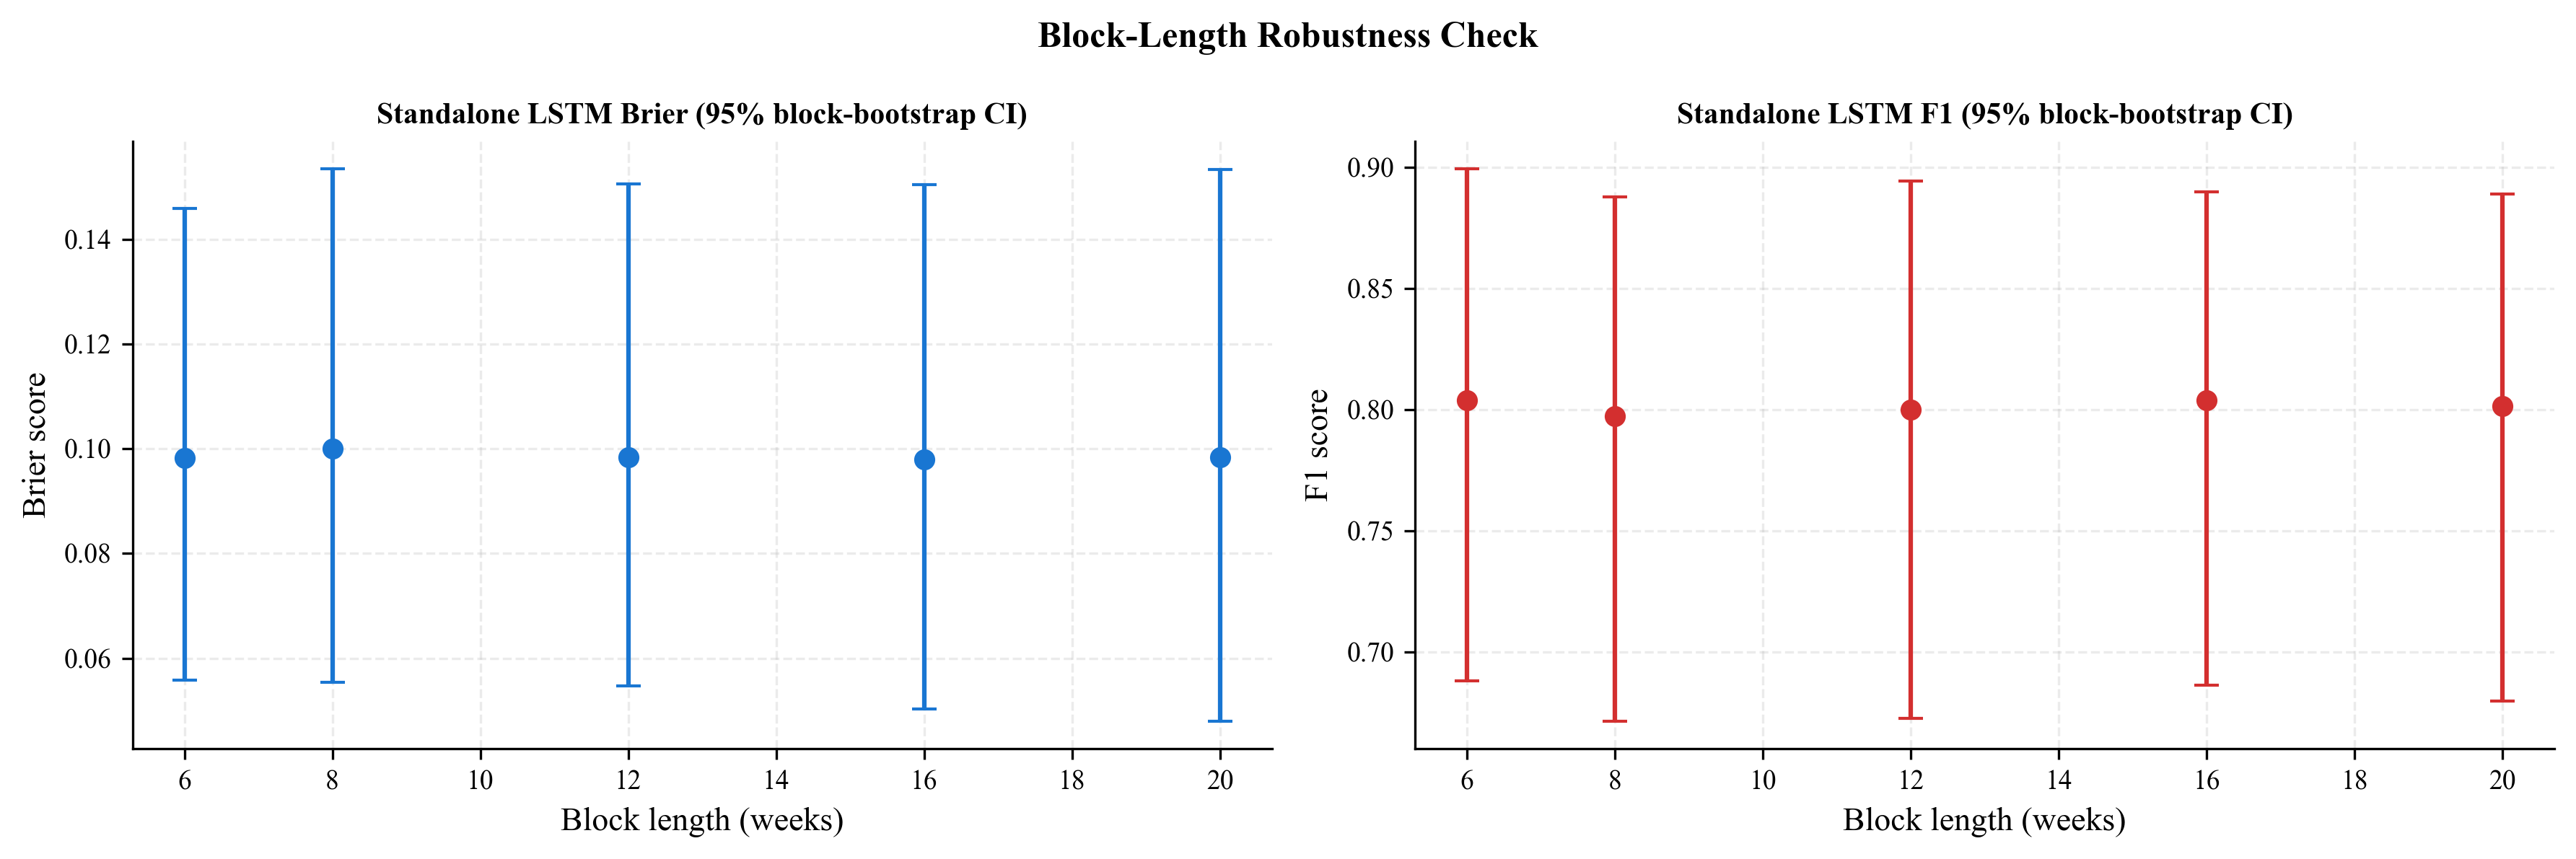


Adopting block length L = 12 weeks for all downstream analyses.


In [4]:
N_BOOT = 1000
BLOCK_LENGTHS = [6, 8, 12, 16, 20]

robustness_rows = []
rng = np.random.default_rng(SEED)
lstm_probs = streams["lstm"]
y, p = align_tail(y_test, lstm_probs)

for L in BLOCK_LENGTHS:
    briers, f1s = [], []
    for _ in range(N_BOOT):
        idx = moving_block_bootstrap_indices(len(y), L, len(y), rng)
        briers.append(float(brier_score_loss(y[idx], p[idx])))
        pred = (p[idx] >= STANDALONE_THRESHOLD).astype(int)
        f1s.append(float(f1_score(y[idx], pred, zero_division=0)))
    robustness_rows.append({
        "block_length": L,
        "brier_mean": float(np.mean(briers)),
        "brier_ci_lo": float(np.percentile(briers, 2.5)),
        "brier_ci_hi": float(np.percentile(briers, 97.5)),
        "brier_ci_width": float(np.percentile(briers, 97.5) - np.percentile(briers, 2.5)),
        "f1_mean": float(np.mean(f1s)),
        "f1_ci_lo": float(np.percentile(f1s, 2.5)),
        "f1_ci_hi": float(np.percentile(f1s, 97.5)),
        "f1_ci_width": float(np.percentile(f1s, 97.5) - np.percentile(f1s, 2.5)),
    })

robust_df = pd.DataFrame(robustness_rows)
save_table(robust_df, "Table9_block_length_robustness.csv",
           "Brier and F1 CI as a function of block length")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].errorbar(robust_df["block_length"], robust_df["brier_mean"],
                 yerr=[robust_df["brier_mean"] - robust_df["brier_ci_lo"],
                       robust_df["brier_ci_hi"] - robust_df["brier_mean"]],
                 fmt="o", capsize=4, color="#1976D2")
axes[0].set_xlabel("Block length (weeks)"); axes[0].set_ylabel("Brier score")
axes[0].set_title("Standalone LSTM Brier (95% block-bootstrap CI)", fontweight="bold", fontsize=10)
axes[0].grid(alpha=0.25, linestyle="--")

axes[1].errorbar(robust_df["block_length"], robust_df["f1_mean"],
                 yerr=[robust_df["f1_mean"] - robust_df["f1_ci_lo"],
                       robust_df["f1_ci_hi"] - robust_df["f1_mean"]],
                 fmt="o", capsize=4, color="#D32F2F")
axes[1].set_xlabel("Block length (weeks)"); axes[1].set_ylabel("F1 score")
axes[1].set_title("Standalone LSTM F1 (95% block-bootstrap CI)", fontweight="bold", fontsize=10)
axes[1].grid(alpha=0.25, linestyle="--")

fig.suptitle("Block-Length Robustness Check", fontweight="bold")
plt.tight_layout()
savefig(fig, "Fig9L_block_length_robustness")
plt.show()

# Adopt L = 12 going forward (consistent with typical bloom-cluster duration).
BLOCK_LENGTH = 12
print(f"\nAdopting block length L = {BLOCK_LENGTH} weeks for all downstream analyses.")


## Bootstrap-method audit: model-level CIs (Table 3)

We re-compute the standalone LSTM and LSTM-EnKF aggregate metrics' 95% CIs under both IID and block bootstrap at L = 12. The expectation is that block-bootstrap intervals are *modestly wider* than IID intervals (because the effective sample size is smaller once autocorrelation is accounted for). If the difference is negligible the manuscript labeling is harmless; if it's substantial the conclusions about overlapping CIs in Table 3 may need recomputation.

In [5]:
def compute_aggregate_metrics(y, p, threshold):
    """Return Brier, AUROC, plus precision/recall/F1 at the given threshold."""
    pred = (p >= threshold).astype(int)
    out = {}
    try:
        out["AUROC"] = float(roc_auc_score(y, p))
    except ValueError:
        out["AUROC"] = np.nan
    out["Brier"] = float(brier_score_loss(y, p))
    out["accuracy"] = float(accuracy_score(y, pred))
    out["precision"] = float(precision_score(y, pred, zero_division=0))
    out["recall"] = float(recall_score(y, pred, zero_division=0))
    out["F1"] = float(f1_score(y, pred, zero_division=0))
    return out


def bootstrap_ci_for_model(y, p, threshold, scheme, n_boot, rng, block_length=12):
    """Return dict[metric] -> (mean, ci_lo, ci_hi) under the given scheme."""
    accum = {k: [] for k in ("AUROC", "Brier", "accuracy", "precision", "recall", "F1")}
    n = len(y)
    for _ in range(n_boot):
        if scheme == "iid":
            idx = iid_bootstrap_indices(n, n, rng)
        else:
            idx = moving_block_bootstrap_indices(n, block_length, n, rng)
        m = compute_aggregate_metrics(y[idx], p[idx], threshold)
        for k in accum:
            if np.isfinite(m[k]):
                accum[k].append(m[k])
    summary = {}
    for k, vals in accum.items():
        if not vals:
            summary[k] = (np.nan, np.nan, np.nan)
        else:
            summary[k] = (float(np.mean(vals)),
                          float(np.percentile(vals, 2.5)),
                          float(np.percentile(vals, 97.5)))
    return summary


rng = np.random.default_rng(SEED)
audit_rows = []

for model_name, spec in [
    ("Standalone LSTM", {"key": "lstm", "threshold": STANDALONE_THRESHOLD}),
    ("LSTM-EnKF",       {"key": "lstm_enkf_preprocessor", "threshold": ENKF_THRESHOLD}),
]:
    y, p = align_tail(y_test, streams[spec["key"]])
    iid_summary = bootstrap_ci_for_model(y, p, spec["threshold"], "iid", N_BOOT, rng)
    blk_summary = bootstrap_ci_for_model(y, p, spec["threshold"], "block", N_BOOT, rng, BLOCK_LENGTH)
    for metric in ("AUROC", "Brier", "accuracy", "precision", "recall", "F1"):
        iid_mean, iid_lo, iid_hi = iid_summary[metric]
        blk_mean, blk_lo, blk_hi = blk_summary[metric]
        audit_rows.append({
            "model": model_name,
            "metric": metric,
            "point_estimate": iid_mean,  # same under both schemes asymptotically
            "iid_ci_lo": iid_lo, "iid_ci_hi": iid_hi,
            "iid_ci_width": iid_hi - iid_lo,
            "block_ci_lo": blk_lo, "block_ci_hi": blk_hi,
            "block_ci_width": blk_hi - blk_lo,
            "width_ratio_block_over_iid": (blk_hi - blk_lo) / max(iid_hi - iid_lo, 1e-12),
        })

audit_df = pd.DataFrame(audit_rows)
save_table(audit_df, "Table9_block_bootstrap_audit.csv",
           "Table 3 model-level CIs: IID vs block bootstrap (L=12)")

print("\nInterpretation:")
print(f"- Mean width ratio (block/IID): {audit_df['width_ratio_block_over_iid'].mean():.3f}")
print("- Ratios > 1 mean block-bootstrap CIs are wider, as expected when autocorrelation is present.")
print("- If the ratio is close to 1.0 across metrics, the manuscript's 'block-bootstrap' label is")
print("  effectively harmless. If ratios are substantially > 1.2, Table 3 CIs should be updated.")


  saved output_refactored/block_bootstrap\Table9_block_bootstrap_audit.csv
  Table 3 model-level CIs: IID vs block bootstrap (L=12)


,model,metric,point_estimate,iid_ci_lo,iid_ci_hi,iid_ci_width,block_ci_lo,block_ci_hi,block_ci_width,width_ratio_block_over_iid
0,Standalone LSTM,AUROC,0.946298,0.917470,0.972168,0.054698,0.882357,0.983859,0.101502,1.855671
1,Standalone LSTM,Brier,0.099000,0.073412,0.125230,0.051818,0.050333,0.150225,0.099891,1.927718
2,Standalone LSTM,accuracy,0.852676,0.805556,0.898148,0.092593,0.777778,0.930556,0.152778,1.650000
3,Standalone LSTM,precision,0.703328,0.612893,0.795699,0.182806,0.544304,0.838719,0.294415,1.610535
4,Standalone LSTM,recall,0.943953,0.883328,0.986667,0.103339,0.867893,0.987952,0.120059,1.161798
5,Standalone LSTM,F1,0.805091,0.739394,0.870114,0.130720,0.681794,0.894559,0.212765,1.627640
6,LSTM-EnKF,AUROC,0.936299,0.901890,0.963721,0.061831,0.863979,0.978198,0.114219,1.847286
7,LSTM-EnKF,Brier,0.148238,0.116133,0.182860,0.066727,0.088721,0.218059,0.129338,1.938314
8,LSTM-EnKF,accuracy,0.763815,0.708333,0.819444,0.111111,0.662037,0.865741,0.203704,1.833333
9,LSTM-EnKF,precision,0.582065,0.491132,0.669298,0.178166,0.402241,0.731132,0.328891,1.845979



Interpretation:
- Mean width ratio (block/IID): 1.721
- Ratios > 1 mean block-bootstrap CIs are wider, as expected when autocorrelation is present.
- If the ratio is close to 1.0 across metrics, the manuscript's 'block-bootstrap' label is
  effectively harmless. If ratios are substantially > 1.2, Table 3 CIs should be updated.


## Bootstrap-method audit: validator paired tests (notebook 09)

Notebook 09's cell 24 paired-bootstrap test currently uses IID resampling. We re-run the same test with block resampling, using shared indices across the two validators within each resample so the pairing is preserved (we are asking: *for the same resample of weeks, what is the difference between EnKF and Standalone in metric X?*).

This is the operationally important fix because the Holm-corrected p-values that gate the validator comparison feed directly into the new §3.4 of the manuscript.

In [6]:
def disagreement_signal(alt_prob, val_prob, val_threshold):
    alt_prob = np.asarray(alt_prob, dtype=float)
    val_prob = np.asarray(val_prob, dtype=float)
    gap = np.abs(alt_prob - val_prob)
    gap_pos = max(1.0 - float(val_threshold), 1e-6)
    gap_neg = max(float(val_threshold), 1e-6)
    val_conf = np.where(
        val_prob >= val_threshold,
        (val_prob - val_threshold) / gap_pos,
        (val_threshold - val_prob) / gap_neg,
    )
    return gap * np.clip(val_conf, 0.0, 1.0)


def safe_auc(y, score):
    try:
        if len(np.unique(y)) < 2:
            return np.nan
        return float(roc_auc_score(y, score))
    except Exception:
        return np.nan


def validator_metrics(y, alt_prob, val_prob, val_threshold):
    """Same metric set used in nb09 cell 24's metric_for_validator()."""
    alt_pred = (alt_prob >= 0.5).astype(int)
    val_pred = (val_prob >= val_threshold).astype(int)
    agree = alt_pred == val_pred
    disagree = ~agree
    alt_wrong = alt_pred != y
    alt_fp = (alt_pred == 1) & (y == 0)
    alt_fn = (alt_pred == 0) & (y == 1)
    disputed_positive = (alt_pred == 1) & (val_pred == 0)
    disputed_negative = (alt_pred == 0) & (val_pred == 1)

    contradiction = disagreement_signal(alt_prob, val_prob, val_threshold)
    adjudicated_prob = np.where(agree, alt_prob, val_prob)
    adjudicated_pred = np.where(agree, alt_pred, val_pred)

    base_f1 = f1_score(y, alt_pred, zero_division=0)
    base_brier = brier_score_loss(y, alt_prob)
    adj_f1 = f1_score(y, adjudicated_pred, zero_division=0)
    adj_brier = brier_score_loss(y, adjudicated_prob)

    FA_MIN = 5
    fa_capture = (float((alt_fp & disputed_positive).sum() / alt_fp.sum())
                  if alt_fp.sum() >= FA_MIN else np.nan)
    me_capture = (float((alt_fn & disputed_negative).sum() / alt_fn.sum())
                  if alt_fn.sum() >= FA_MIN else np.nan)

    return {
        "error_detection_AUROC":      safe_auc(alt_wrong.astype(int), contradiction),
        "accepted_accuracy":          (float(accuracy_score(y[agree], alt_pred[agree]))
                                       if agree.any() else np.nan),
        "flag_precision_alt_wrong":   (float((alt_wrong & disagree).sum() / disagree.sum())
                                       if disagree.any() else np.nan),
        "error_capture_by_flags":     (float((alt_wrong & disagree).sum() / alt_wrong.sum())
                                       if alt_wrong.any() else np.nan),
        "false_alarm_capture":        fa_capture,
        "missed_event_capture":       me_capture,
        "adjudicated_delta_F1":       float(adj_f1 - base_f1),
        "adjudicated_delta_Brier":    float(adj_brier - base_brier),
    }


STAT_METRICS = {
    "error_detection_AUROC":    {"higher_better": True},
    "accepted_accuracy":        {"higher_better": True},
    "flag_precision_alt_wrong": {"higher_better": True},
    "error_capture_by_flags":   {"higher_better": True},
    "false_alarm_capture":      {"higher_better": True},
    "missed_event_capture":     {"higher_better": True},
    "adjudicated_delta_F1":     {"higher_better": True},
    "adjudicated_delta_Brier":  {"higher_better": False},
}


def holm_adjust(p_values):
    p = np.asarray(p_values, dtype=float)
    out = np.full_like(p, np.nan, dtype=float)
    finite = np.isfinite(p)
    if not finite.any():
        return out
    idx = np.where(finite)[0]
    order = idx[np.argsort(p[idx])]
    m = len(order); running = 0.0
    for rank, original_idx in enumerate(order):
        adjusted = min(1.0, (m - rank) * p[original_idx])
        running = max(running, adjusted)
        out[original_idx] = running
    return out


def bootstrap_p_two_sided(diffs):
    diffs = np.asarray(diffs, dtype=float)
    diffs = diffs[np.isfinite(diffs)]
    if not len(diffs):
        return np.nan
    return float(min(1.0, 2.0 * min(np.mean(diffs <= 0), np.mean(diffs >= 0))))


def run_validator_paired_bootstrap(scheme, n_boot, block_length=12, target_length=None, seed=SEED):
    """Returns a long-format DataFrame: (alt_model, metric) x bootstrap stats."""
    rng = np.random.default_rng(seed)
    rows = []
    standalone = validator_specs["Standalone LSTM"]
    enkf = validator_specs["LSTM-EnKF validator"]

    for alt_key in alternate_keys:
        y, alt_prob, p_std, p_enk = align_tail(
            y_test, streams[alt_key],
            streams[standalone["key"]], streams[enkf["key"]],
        )
        n = len(y)
        T = target_length if target_length else n
        boot_by_metric = {m: [] for m in STAT_METRICS}
        for _ in range(n_boot):
            if scheme == "iid":
                idx = iid_bootstrap_indices(n, T, rng)
            else:
                idx = moving_block_bootstrap_indices(n, block_length, T, rng)
            yb, ab = y[idx], alt_prob[idx]
            std_b, enk_b = p_std[idx], p_enk[idx]
            m_std = validator_metrics(yb, ab, std_b, standalone["threshold"])
            m_enk = validator_metrics(yb, ab, enk_b, enkf["threshold"])
            for metric in STAT_METRICS:
                d = m_enk[metric] - m_std[metric]
                if np.isfinite(d):
                    boot_by_metric[metric].append(d)

        # Point estimates on the original (un-resampled) data
        std_point = validator_metrics(y, alt_prob, p_std, standalone["threshold"])
        enk_point = validator_metrics(y, alt_prob, p_enk, enkf["threshold"])

        for metric, cfg in STAT_METRICS.items():
            diffs = np.asarray(boot_by_metric[metric], dtype=float)
            diffs = diffs[np.isfinite(diffs)]
            if not len(diffs):
                rows.append({
                    "alternative_model": name_map[alt_key], "metric": metric,
                    "scheme": scheme, "target_length": T,
                    "diff_enkf_minus_standalone": np.nan,
                    "ci_lo": np.nan, "ci_hi": np.nan,
                    "p_raw": np.nan, "n_valid": 0,
                })
                continue
            point_diff = enk_point[metric] - std_point[metric]
            ci_lo = float(np.percentile(diffs, 2.5))
            ci_hi = float(np.percentile(diffs, 97.5))
            p_raw = bootstrap_p_two_sided(diffs)
            rows.append({
                "alternative_model": name_map[alt_key], "metric": metric,
                "scheme": scheme, "target_length": T,
                "diff_enkf_minus_standalone": float(point_diff),
                "ci_lo": ci_lo, "ci_hi": ci_hi,
                "p_raw": float(p_raw), "n_valid": int(len(diffs)),
            })

    df = pd.DataFrame(rows)
    df["p_holm"] = holm_adjust(df["p_raw"].values)
    df["holm_significant_0.05"] = df["p_holm"] < 0.05
    return df


print("Running validator paired bootstrap under IID scheme (replicates nb09 cell 24)...")
t0 = time.time()
iid_df = run_validator_paired_bootstrap("iid", n_boot=2000, target_length=n_test)
print(f"  IID done in {time.time()-t0:.1f}s. Holm-significant: {int(iid_df['holm_significant_0.05'].sum())}/{len(iid_df)}")

print(f"\nRunning validator paired bootstrap under BLOCK scheme (L={BLOCK_LENGTH})...")
t0 = time.time()
blk_df = run_validator_paired_bootstrap("block", n_boot=2000, block_length=BLOCK_LENGTH, target_length=n_test)
print(f"  Block done in {time.time()-t0:.1f}s. Holm-significant: {int(blk_df['holm_significant_0.05'].sum())}/{len(blk_df)}")

# Side-by-side comparison
combined = iid_df.merge(
    blk_df[["alternative_model", "metric", "ci_lo", "ci_hi", "p_raw", "p_holm", "holm_significant_0.05"]],
    on=["alternative_model", "metric"], suffixes=("_iid", "_block"),
)
combined["ci_width_iid"] = combined["ci_hi_iid"] - combined["ci_lo_iid"]
combined["ci_width_block"] = combined["ci_hi_block"] - combined["ci_lo_block"]
combined["width_ratio"] = combined["ci_width_block"] / np.maximum(combined["ci_width_iid"], 1e-12)

cols_to_save = [
    "alternative_model", "metric", "diff_enkf_minus_standalone",
    "ci_lo_iid", "ci_hi_iid", "p_holm_iid",
    "ci_lo_block", "ci_hi_block", "p_holm_block",
    "ci_width_iid", "ci_width_block", "width_ratio",
]
save_table(combined[cols_to_save],
           "Table9_validator_block_bootstrap.csv",
           "Validator paired bootstrap: IID vs block (n_boot=2000, L=12)")

# Headline
n_iid_sig = int(iid_df["holm_significant_0.05"].sum())
n_blk_sig = int(blk_df["holm_significant_0.05"].sum())
print(f"\nHolm-significant comparisons (alpha = 0.05):")
print(f"  IID bootstrap:   {n_iid_sig:>2d} / {len(iid_df)}")
print(f"  Block bootstrap: {n_blk_sig:>2d} / {len(blk_df)}")
print(f"  Mean CI-width ratio (block/IID): {combined['width_ratio'].mean():.3f}")


Running validator paired bootstrap under IID scheme (replicates nb09 cell 24)...
  IID done in 40.7s. Holm-significant: 11/40

Running validator paired bootstrap under BLOCK scheme (L=12)...
  Block done in 40.6s. Holm-significant: 4/40
  saved output_refactored/block_bootstrap\Table9_validator_block_bootstrap.csv
  Validator paired bootstrap: IID vs block (n_boot=2000, L=12)


,alternative_model,metric,diff_enkf_minus_standalone,ci_lo_iid,ci_hi_iid,p_holm_iid,ci_lo_block,ci_hi_block,p_holm_block,ci_width_iid,ci_width_block,width_ratio
0,VAR,error_detection_AUROC,0.019444,-0.074207,0.116654,1.000000,-0.108386,0.160469,1.000000,0.190861,0.268856,1.408644
1,VAR,accepted_accuracy,0.001529,-0.026193,0.030610,1.000000,-0.039813,0.040286,1.000000,0.056803,0.080099,1.410110
2,VAR,flag_precision_alt_wrong,-0.133117,-0.209988,-0.063946,0.000000,-0.237575,-0.038450,0.108000,0.146042,0.199125,1.363477
3,VAR,error_capture_by_flags,0.027778,-0.093750,0.157925,1.000000,-0.125000,0.260870,1.000000,0.251675,0.385870,1.533208
4,VAR,false_alarm_capture,NaN,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
5,VAR,missed_event_capture,0.029412,-0.100000,0.166667,1.000000,-0.135485,0.273119,1.000000,0.266667,0.408604,1.532264
6,VAR,adjudicated_delta_F1,-0.080554,-0.133790,-0.032821,0.033000,-0.166058,-0.018111,0.232000,0.100969,0.147947,1.465265
7,VAR,adjudicated_delta_Brier,0.047194,0.027950,0.067092,0.000000,0.015329,0.081585,0.000000,0.039142,0.066256,1.692711
8,Regime-switching,error_detection_AUROC,0.095292,-0.003927,0.199157,1.000000,-0.039889,0.240274,1.000000,0.203083,0.280163,1.379547
9,Regime-switching,accepted_accuracy,-0.022802,-0.041758,-0.007939,0.000000,-0.035411,-0.001942,0.108000,0.033819,0.033469,0.989641



Holm-significant comparisons (alpha = 0.05):
  IID bootstrap:   11 / 40
  Block bootstrap:  4 / 40
  Mean CI-width ratio (block/IID): 1.233


## Power analysis: at what sample size do validator differences become detectable?

We re-run the paired block-bootstrap with target lengths set to multiples of the real test length: 1×, 2×, 5×, and 10× (i.e., 216, 432, 1080, 2160 weeks). Each resample preserves bloom-week clustering by drawing 12-week blocks from the original 216 weeks; oversampling at scales > 1 means individual onsets are sampled multiple times per resample.

**What this measures.** At each scale, the Holm-corrected p-value for each (alt model × metric) test under the null hypothesis "validator-differences-equal-zero." If a directional difference (5/5 sign pattern in nb09) reflects a real effect, p-values should fall below 0.05 at some scale. If they remain near 1.0 at all scales, the null result is structural rather than sample-size-limited.

**What this does *not* measure.** It does not estimate the validator differences that would emerge under a different bloom regime. Onset events are reused across resamples; they are not fresh draws from the bloom-generating process. The power curves answer "more of the same kind of data" only.

In [7]:
POWER_SCALES = [1, 2, 5, 10]
POWER_N_BOOT = 1500  # smaller than the audit because we run it 4 times

power_dfs = {}
for scale in POWER_SCALES:
    target_n = n_test * scale
    print(f"\nPower analysis at scale {scale}x (target length = {target_n} weeks)...")
    t0 = time.time()
    df = run_validator_paired_bootstrap(
        "block", n_boot=POWER_N_BOOT, block_length=BLOCK_LENGTH,
        target_length=target_n, seed=SEED + scale,
    )
    df["scale"] = scale
    df["target_length"] = target_n
    n_sig = int(df["holm_significant_0.05"].sum())
    print(f"  done in {time.time()-t0:.1f}s. Holm-significant at alpha=0.05: {n_sig}/{len(df)}")
    power_dfs[scale] = df

power_long = pd.concat(power_dfs.values(), ignore_index=True)
save_table(
    power_long[["alternative_model", "metric", "scale", "target_length",
                "diff_enkf_minus_standalone", "ci_lo", "ci_hi",
                "p_raw", "p_holm", "holm_significant_0.05"]],
    "Table9_power_analysis.csv",
    f"Holm-corrected p-values at scales {POWER_SCALES} (block bootstrap, L={BLOCK_LENGTH})",
)



Power analysis at scale 1x (target length = 216 weeks)...
  done in 30.8s. Holm-significant at alpha=0.05: 6/40

Power analysis at scale 2x (target length = 432 weeks)...
  done in 31.4s. Holm-significant at alpha=0.05: 14/40

Power analysis at scale 5x (target length = 1080 weeks)...
  done in 34.3s. Holm-significant at alpha=0.05: 24/40

Power analysis at scale 10x (target length = 2160 weeks)...
  done in 38.3s. Holm-significant at alpha=0.05: 27/40
  saved output_refactored/block_bootstrap\Table9_power_analysis.csv
  Holm-corrected p-values at scales [1, 2, 5, 10] (block bootstrap, L=12)


,alternative_model,metric,scale,target_length,diff_enkf_minus_standalone,ci_lo,ci_hi,p_raw,p_holm,holm_significant_0.05
0,VAR,error_detection_AUROC,1,216,0.019444,-0.101344,0.165015,0.686667,1.000000,False
1,VAR,accepted_accuracy,1,216,0.001529,-0.037697,0.039038,0.860000,1.000000,False
2,VAR,flag_precision_alt_wrong,1,216,-0.133117,-0.236354,-0.036862,0.002667,0.090667,False
3,VAR,error_capture_by_flags,1,216,0.027778,-0.118382,0.237500,0.790667,1.000000,False
4,VAR,false_alarm_capture,1,216,NaN,0.000000,0.000000,1.000000,1.000000,False
...,...,...,...,...,...,...,...,...,...,...
155,Hybrid ensemble,error_capture_by_flags,10,2160,0.187500,0.129674,0.257485,0.000000,0.000000,True
156,Hybrid ensemble,false_alarm_capture,10,2160,0.000000,0.000000,0.000000,1.000000,1.000000,False
157,Hybrid ensemble,missed_event_capture,10,2160,0.428571,0.298772,0.557266,0.000000,0.000000,True
158,Hybrid ensemble,adjudicated_delta_F1,10,2160,-0.080554,-0.101699,-0.055435,0.000000,0.000000,True


## Power curves figure

For each (alt model × metric) test, we plot Holm-corrected p-value as a function of effective sample-size scale, with a horizontal reference line at α = 0.05. Lines that *cross* the line as scale increases indicate effects that are detectable with more data; lines that stay above the line at 10× suggest the null result is structural.

Note: because Holm adjustment is applied across the full family of (alt model × metric) tests within each scale, the p-values are comparable across panels at the same scale but conservative; a per-metric Holm correction would give a less conservative picture.

  saved output_refactored/block_bootstrap\Fig9M_power_analysis.png
  saved output_refactored/block_bootstrap\Fig9M_power_analysis.pdf


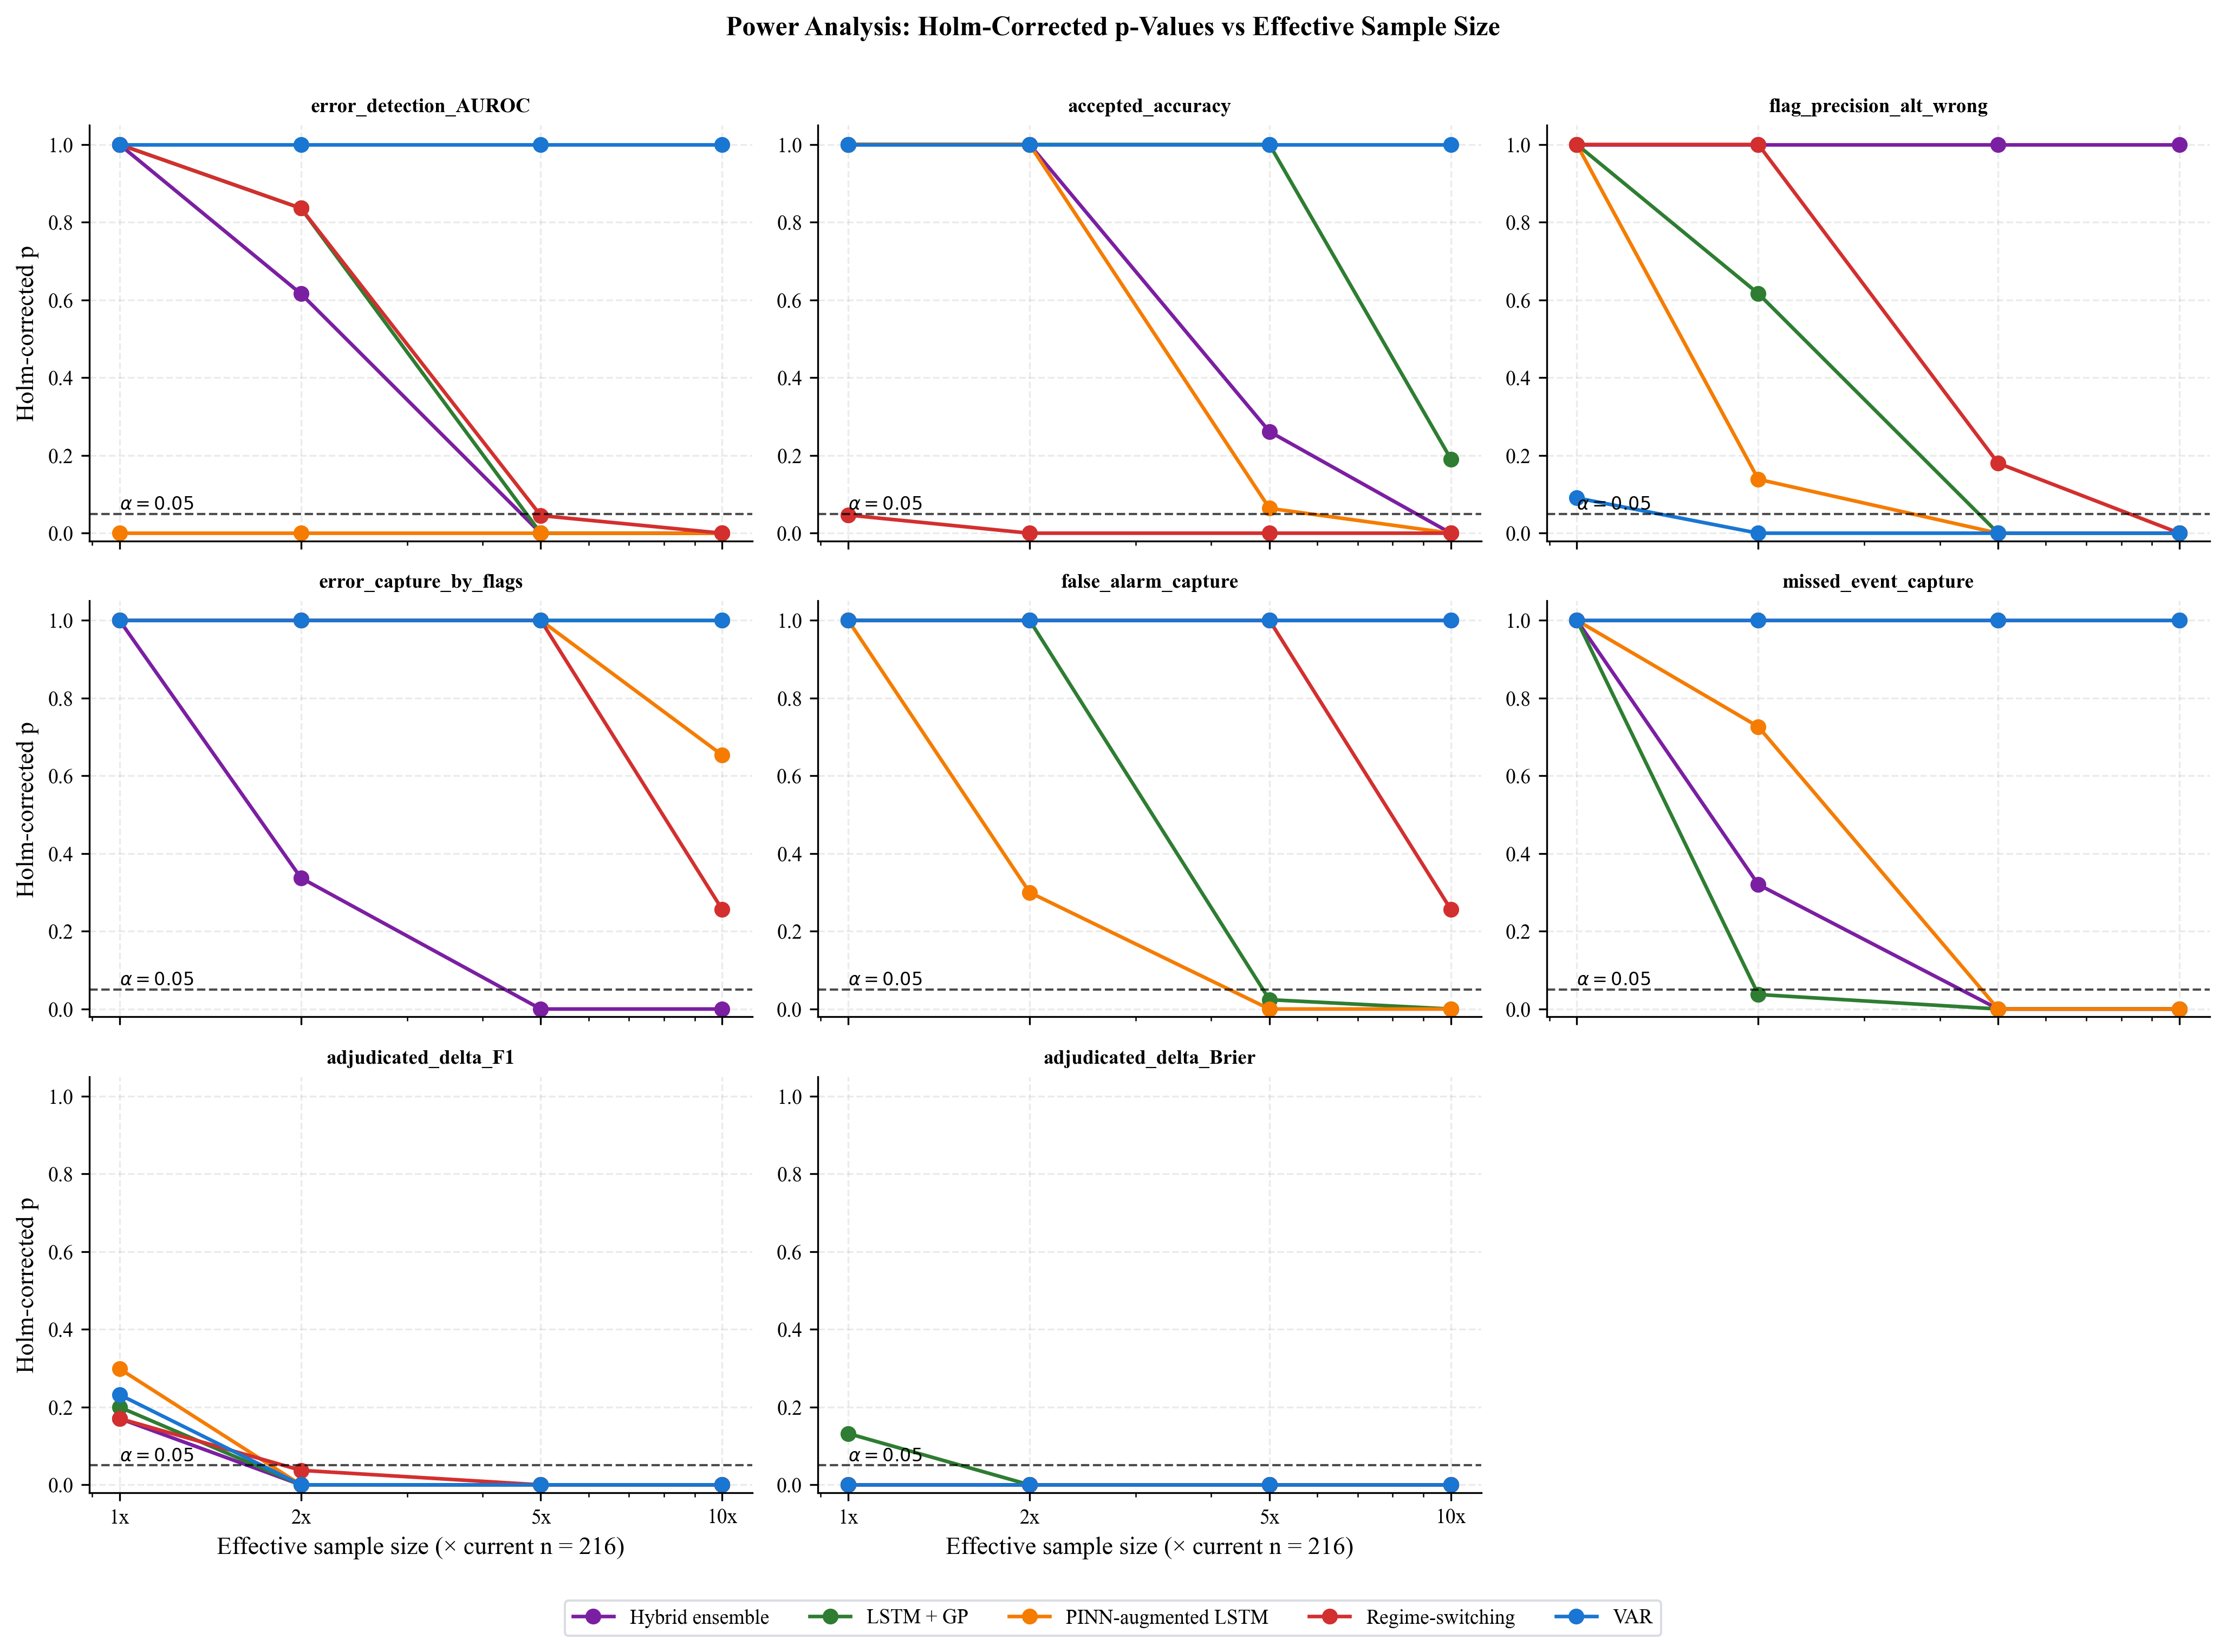

  saved output_refactored/block_bootstrap\Table9_power_summary.csv
  Summary: which validator-comparisons become Holm-significant at scale 10x


,alternative_model,metric,p_holm_at_1x,p_holm_at_10x,ever_significant,first_significant_scale
0,Hybrid ensemble,accepted_accuracy,1.000000,0.000000,True,10.0
1,Hybrid ensemble,adjudicated_delta_Brier,0.000000,0.000000,True,1.0
2,Hybrid ensemble,adjudicated_delta_F1,0.170667,0.000000,True,2.0
3,Hybrid ensemble,error_capture_by_flags,1.000000,0.000000,True,5.0
4,Hybrid ensemble,error_detection_AUROC,1.000000,0.000000,True,5.0
7,Hybrid ensemble,missed_event_capture,1.000000,0.000000,True,5.0
9,LSTM + GP,adjudicated_delta_Brier,0.132000,0.000000,True,2.0
10,LSTM + GP,adjudicated_delta_F1,0.200000,0.000000,True,2.0
12,LSTM + GP,error_detection_AUROC,1.000000,0.000000,True,5.0
13,LSTM + GP,false_alarm_capture,1.000000,0.000000,True,5.0



HEADLINE: 27/40 validator-comparisons become Holm-significant at any tested scale up to 10x.
These specific comparisons would become detectable with more data of the same kind.


In [8]:
metrics_to_plot = list(STAT_METRICS.keys())
n_metrics = len(metrics_to_plot)
n_cols = 3
n_rows = int(np.ceil(n_metrics / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.6 * n_cols, 3.2 * n_rows), sharex=True)
axes = axes.flatten()

COLORS = {"VAR": "#1976D2", "Regime-switching": "#D32F2F",
          "PINN-augmented LSTM": "#F57C00", "LSTM + GP": "#2E7D32",
          "Hybrid ensemble": "#7B1FA2"}

for ax_i, metric in enumerate(metrics_to_plot):
    ax = axes[ax_i]
    sub = power_long[power_long["metric"] == metric]
    for alt_name in sorted(sub["alternative_model"].unique()):
        s = sub[sub["alternative_model"] == alt_name].sort_values("scale")
        ax.plot(s["scale"], s["p_holm"], marker="o",
                color=COLORS.get(alt_name, "#455A64"), lw=1.6, label=alt_name)
    ax.axhline(0.05, color="black", linestyle="--", lw=1, alpha=0.7)
    ax.text(POWER_SCALES[0], 0.052, r"$\alpha = 0.05$", fontsize=8, va="bottom")
    ax.set_xscale("log")
    ax.set_xticks(POWER_SCALES)
    ax.set_xticklabels([f"{s}x" for s in POWER_SCALES])
    ax.set_ylim(-0.02, 1.05)
    ax.set_title(metric, fontsize=9, fontweight="bold")
    ax.grid(alpha=0.25, linestyle="--")
    if ax_i % n_cols == 0:
        ax.set_ylabel("Holm-corrected p")
    if ax_i // n_cols == n_rows - 1:
        ax.set_xlabel(f"Effective sample size (× current n = {n_test})")

# Hide any unused axes
for ax_i in range(n_metrics, len(axes)):
    axes[ax_i].set_visible(False)

# Shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, -0.04),
           ncol=min(5, len(labels)), frameon=True, edgecolor="#D1D5DB")
fig.suptitle("Power Analysis: Holm-Corrected p-Values vs Effective Sample Size",
             fontweight="bold", y=1.005)
plt.tight_layout()
savefig(fig, "Fig9M_power_analysis")
plt.show()

# Headline summary text
crossing_rows = []
for (alt, metric), group in power_long.groupby(["alternative_model", "metric"]):
    g = group.sort_values("scale")
    p_at_1x = float(g[g["scale"] == 1]["p_holm"].iloc[0])
    p_at_10x = float(g[g["scale"] == max(POWER_SCALES)]["p_holm"].iloc[0])
    crosses = bool((g["p_holm"] < 0.05).any())
    first_cross = (int(g[g["p_holm"] < 0.05]["scale"].min()) if crosses else None)
    crossing_rows.append({
        "alternative_model": alt, "metric": metric,
        "p_holm_at_1x": p_at_1x, "p_holm_at_10x": p_at_10x,
        "ever_significant": crosses, "first_significant_scale": first_cross,
    })
crossing_df = pd.DataFrame(crossing_rows).sort_values(["ever_significant", "p_holm_at_10x"], ascending=[False, True])
save_table(crossing_df, "Table9_power_summary.csv",
           "Summary: which validator-comparisons become Holm-significant at scale 10x")

n_ever = int(crossing_df["ever_significant"].sum())
print(f"\nHEADLINE: {n_ever}/{len(crossing_df)} validator-comparisons become Holm-significant at any tested scale up to 10x.")
if n_ever == 0:
    print("This is the structural-null result: the directional patterns in nb09 do not amplify into")
    print("significance with more data of the same kind. The validators are interchangeable on this regime.")
else:
    print("These specific comparisons would become detectable with more data of the same kind.")


## Persistence

Tables and figures are written to `output_refactored/block_bootstrap/`. The CSV outputs are formatted to drop into the manuscript supplementary tables. The key result for §3.4 of the paper is the power-summary table — specifically the count of comparisons that become significant at 10× and the smallest scale at which any do.

In [9]:
POWER_ANALYSIS_NPZ = os.path.join(INTERMEDIATE_DIR, "block_bootstrap_results.npz")
np.savez(
    POWER_ANALYSIS_NPZ,
    audit_rows=audit_df.to_dict(orient="records"),
    iid_validator=iid_df.to_dict(orient="records"),
    block_validator=blk_df.to_dict(orient="records"),
    power_long=power_long.to_dict(orient="records"),
    crossing_summary=crossing_df.to_dict(orient="records"),
    block_length=BLOCK_LENGTH,
    n_boot_audit=2000,
    n_boot_power=POWER_N_BOOT,
    scales=POWER_SCALES,
)
print(f"Saved {POWER_ANALYSIS_NPZ}")
print("\nNext step: incorporate Fig 9M and Table 9 power-summary into manuscript section 3.4.")


Saved output_refactored/intermediate\block_bootstrap_results.npz

Next step: incorporate Fig 9M and Table 9 power-summary into manuscript section 3.4.
